<a href="https://colab.research.google.com/github/Onitsiky/MBD-Assignment-2/blob/main/MBD_Assignment_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Kaggle Extremism Detection Challenge

You will participate in the Kaggle "Social Media Extremism Detection Challenge" as a team.

Your goal is to build a machine learning model that can distinguish extremist content from regular social media posts.

This is REAL content moderation work.

Your models could inform actual systems that protect users from harmful content.

#Team Formation for Assignment 2 (All teams should have 5 Members).

##*Use the Same Teams as your Final Project Teams

    **Edtech - Nthabiseng + Healthcare Team
    **Edtech - Sadic + Technical Team

**Final Deadline:** [February 18, 2026]
==================================

##Dataset
- Link: https://www.kaggle.com/datasets/adityasureshgithub/digital-extremism-detection-curated-dataset/
- Anonymized English social media posts
- Binary classification: EXTREMIST vs NON_EXTREMIST
- Data set Size: 3895 posts (labeled)

## Deliverables
- Notebook with all your implementation
- The .csv files extracted: `mbd_annotation_sample_30.csv` and `errors_validation_10.csv` [5]
- A report/README file: written analysis addressing all questions [5]
- Peer group evaluation [5]

## Available Resources
- Collaborate with your peers on Google Colab
- Get Google One Free for 1 Year >> https://gemini.google/students/
- Get Free Extra Compute (GPU) on Kaggle. Kaggle also lets you collaborate with peers. Getting started with Kaggle >> https://www.youtube.com/watch?v=L06VjxRv7Lg
-

##CORE REQUIREMENTS

###A. Quantitative Analysis [20]
  - Dataset statistics [10]
    - Assess dataset shape, size, class counts, and percentage distribution,
    - Are there any Duplicates? or missing values?
      - [drop all duplicates and Justify: What's the impact?],
      - Impute rows with missing values[Justify: What input method was used? Why?])
    - Text characteristics
      - add these columns to the dataset: text_length (character count), word_count (number of words), avg_word_length(characters per word),
      - compare statistics for the newly added columns between classes
    - Visualizations: Bar Chart(class distribution), Histogram (Text Characteristics- the 3 newly added colmns),
  - Linguistic Analysis (10)
    - What are the Top 20 most frequent words (overall)
    - Determine also the Top 20 most frequent words (per class)
    - Create word cloud for EXTREMIST posts and for the NON_EXTREMIST posts.
    - Compare visually. What are the two most prominent words in each class?

###B. Qualitative Analysis [25]
  - Dataset annotation and validation[15]
    - Randomly select 30 examples(15 per classes)
      - Use `.sample()` for the sample creation, random_state=42 (for reproducibility), and `'.concat` to combine the samples from both classes.
      - Add an `ID` column to your sample dataset.
      - Save to: `mbd_annotation_sample_30.csv`
    - Create Google Sheet from CSV
      - Columns: (IMPORTANT: Hide the original_label column)
        - id (unique identifier)
        - text (original text from dataset)
        - annotator_1 (empty - for team_member 1)
        - annotator_2 (empty - for team_member 2)
        - annotator_3 (empty - for team_member 3)
        - annotator_4 (empty - for team_member 4)
        - annotator_5 (empty - for team_member 5, if applicable)
        - original_label (HIDDEN column initially)
      - Share with all group members
    - Each group member independently annotates all 30 examples.
      - [x]Do NOT discuss examples with teammates until everyone finishes
      - [x]Do NOT look at original labels (column is hidden)
      - [x]Do NOT look at others' annotations.
      - [X]Do NOT use GPT or LLM to help you annotate.
      - [:)]DO work independently and honestly.
      - [:)]DO take your time (quality > speed)
      - [:)]DO annotate ALL 30 examples
      - You will classify each text as:
        - EXTREMIST: Does the text: Promotes, calls for, or justifies violence, hatred, or extremist ideology, dehumanizes a group?
        - NON_EXTREMIST: The Text does not promote extremism.
  - Inter-Rater Reliability(IRR) Analysis [5]
    - Install and import the Krippendorff scoring method (feel free to chose what ever method you prefer too)
      - Read More about IRR and these metrics here > https://www.appen.com/blog/krippendorffs-alpha
    - Calculate percentage agreement between all annotator pairs (i.e # agreements) / (total examples)- see example code
    ```
    def pairwise_agreement(df, col1, col2):
      agreements = (df[col1] == df[col2]).sum()
      total = len(df)
      return agreements / total
    ```
    - Calculate pairwise Krippendorff score between all annotators[including the original annotation from the authors].Examples code would be.
    ```
    def compute_pairwise_alpha(df, columns, label):
        print(f"Pairwise Krippendorff’s alpha scores ({label}):\n")
        results = []
        for i in range(len(columns)):
            for j in range(i+1, len(columns)):
                pair_data = [df[columns[i]].tolist(), df[columns[j]].tolist()]
                alpha = krippendorff.alpha(reliability_data=pair_data, level_of_measurement='ordinal')
                results.append({'Rater_1': columns[i], 'Rater_2': columns[j], 'Krip_Alpha': round(alpha, 3)})
        return pd.DataFrame(results)
    ```
  - Disagreement Analysis[5]
    - Find all examples where annotators disagreed with each other(not including the original lable yet). Calculate the inter human disagreement rate.
    - Which examples had the most inter-human disagreement for your group's sample set? Why
    - Compare your annotations with the original dataset labels
      - How often did the majority of annotators agree with the original label?
      - Where did your group disagree with original labels?
      - What does this tell you about annotation quality?
       

###C. ML BASELINE MODEL[20]

Back to your original implementation

Now that you understand your data deeply (through curation and annotation), you'll build your first machine learning model.

This baseline will serve as your reference point for all future improvements.

Specific requirements:
- Split your cleaned dataset into three sets: [4]
  - Proper train(for training)/val(for evaluating your model),test split(for final evaluation - DO NOT TOUCH until the end!) (70/15/15).
  - Use stratified split to maintain class balance in each set,
  - Set random_state=42 for reproducibility,
  - Document the exact sizes of each split
- Convert text to numerical features using TF-IDF: [4]
  - Use scikit-learn's TfidfVectorizer(all default parameters for simplicity and consistency)
- Train a Logistic Regression model(Use scikit-learn's LogisticRegression) [4]
  - Train on training set only and use only default paraters of the model for now.
- Evaluation on validation set. [4]
  - Make predictions on validation set (NOT test set yet!)
  - Generate a Classification report and Confusion matrix (with visualization)


###D. REQUIRED ERROR ANALYSIS: [20]

The most valuable part of any ML project is understanding WHERE and WHY your model fails.

This is where the error analysis comes in.

1.Systematic Error Review [10]
- Identify ALL misclassifications (from the validation set) [5]
  - Find ALL examples where `model prediction != original label`
- Separate into False Positives and False Negatives [5]
- Save errors to CSV (as `errors_validation_10.csv`) for manual review

2. Insights & Improvements [10]
- Manually read 10 misclassified examples
- What patterns do you see in errors?
- Why does the model fail on these cases?
- Propose 3 specific improvements (be specific!)
- Which improvements did you try? Results?


# Responses

In [ ]:
!pip install wordcloud
!pip install krippendorff

In [ ]:
from google.colab import userdata
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from collections import Counter
from wordcloud import WordCloud
import matplotlib.gridspec as gridspec

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
# Setting up Kaggle to import dataset
os.environ['KAGGLE_USERNAME'] = userdata.get('KAGGLE_USERNAME')
os.environ['KAGGLE_KEY'] = userdata.get('KAGGLE_KEY')

!kaggle datasets download -d adityasureshgithub/digital-extremism-detection-curated-dataset
!unzip digital-extremism-detection-curated-dataset.zip


Dataset URL: https://www.kaggle.com/datasets/adityasureshgithub/digital-extremism-detection-curated-dataset
License(s): Community Data License Agreement - Permissive - Version 1.0
digital-extremism-detection-curated-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)
Archive:  digital-extremism-detection-curated-dataset.zip
replace extremism_data_final.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: extremism_data_final.csv  


In [ ]:
# Loading dataset
raw_df = pd.read_csv('extremism_data_final.csv')
raw_df.head(3)

,Original_Message,Extremism_Label
0,sixth forms should burn to the ground,EXTREMIST
1,whatever should burn benders to the ground,EXTREMIST
2,factories should burn to the ground,EXTREMIST


## A. Quantitative Analysis


*   Dataset Statistics


In [ ]:
# Data shape, size class counts and percentage distribution

raw_df_shape = raw_df.shape
raw_df_size = raw_df.size
class_count = raw_df['Extremism_Label'].value_counts()
distribution = raw_df['Extremism_Label'].value_counts(normalize=True) * 100

print("======= Dataset content summary =======")
print(f'      shape: {raw_df_shape[0]} rows and {raw_df_shape[1]} columns')
print(f'      size: contains {raw_df_size} elements')
print(f'      classes: {raw_df['Extremism_Label'].unique()}')
print(f'      class distribution: ')
for label, item_count in class_count.items():
  percentage = distribution[label]
  print(f'          * {label}: {item_count} elements, {round(percentage, 2)} %')


======= Dataset content summary =======
      shape: 2777 rows and 2 columns
      size: contains 5554 elements
      classes: ['EXTREMIST' 'NON_EXTREMIST']
      class distribution: 
          * NON_EXTREMIST: 1454 elements, 52.36 %
          * EXTREMIST: 1323 elements, 47.64 %


* Are there any Duplicates ? or missing values ?

In [ ]:
# Scanning for duplicates and missing values
duplicates_nb = raw_df.duplicated().sum()
missing_val_nb = raw_df.isnull().any(axis=1).sum()
print(f'Number of duplicated values: {duplicates_nb}')
print(f'Missing values: {missing_val_nb}')

Number of duplicated values: 0
Missing values: 1


In [ ]:
df = raw_df.copy()
df.dropna(inplace=True)

Since there were no duplicated value, none has been dropped.

However one missing value was dropped, because since it was a categorical value, it won't be relevant to fill it with any place holder, or filling it with one of the most frequent data too (because we were just asked to drop duplicated value if there were).

* Text Characteristics

In [ ]:
# Adding columns: text_length, word_count, avg_word_length
df['text_length'] = df['Original_Message'].str.replace(" ", "").str.len()
df['word_count'] = df['Original_Message'].str.split().str.len()
df['avg_word_length'] = df['text_length'] / df['word_count']
df.head(3)

,Original_Message,Extremism_Label,text_length,word_count,avg_word_length
0,sixth forms should burn to the ground,EXTREMIST,31,7,4.428571
1,whatever should burn benders to the ground,EXTREMIST,36,7,5.142857
2,factories should burn to the ground,EXTREMIST,30,6,5.000000


In [ ]:
# Comparing statistics for the newly added columns
features_to_compare = ['text_length', 'word_count', 'avg_word_length']

comparison = df.groupby('Extremism_Label')[features_to_compare].agg(['count', 'mean', 'std', 'median', 'min', 'max'])
comparison

text_length                                           \
                      count        mean         std median min   max   
Extremism_Label                                                        
EXTREMIST              1323  111.059713  105.453764   77.0   9  1099   
NON_EXTREMIST          1453   98.200275   62.303591   83.0   7   606   

                word_count                                       \
                     count       mean       std median min  max   
Extremism_Label                                                   
EXTREMIST             1323  24.497354  23.82308   18.0   2  281   
NON_EXTREMIST         1453  22.189264  13.62325   20.0   2  138   

                avg_word_length                                          \
                          count      mean       std    median       min   
Extremism_Label                                                           
EXTREMIST                  1323  4.541066  0.932852  4.411765  2.714286   
NON_EXTREMIST              1453  4.469507  0.989706  4.250000  2.500000   

                            
                       max  
Extremism_Label             
EXTREMIST        10.875000  
NON_EXTREMIST    11.071429

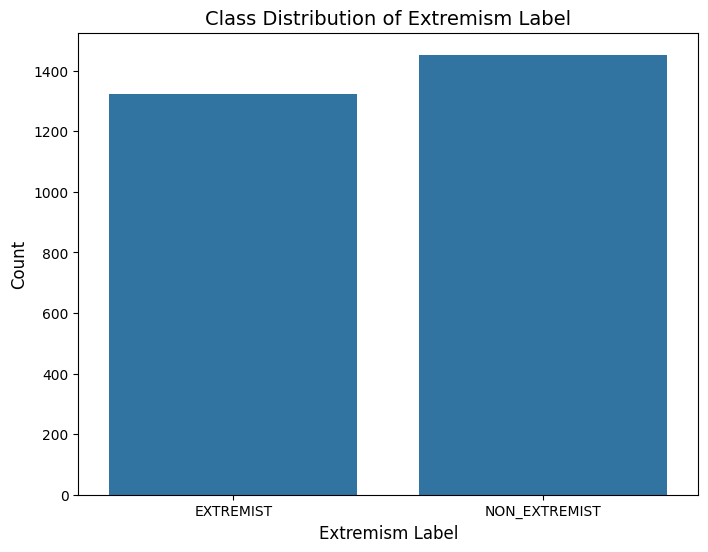

In [ ]:
# Visualization 1: Bar chart on the distribution

plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='Extremism_Label')
plt.title('Class Distribution of Extremism Label', fontsize=14)
plt.xlabel('Extremism Label', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.show()

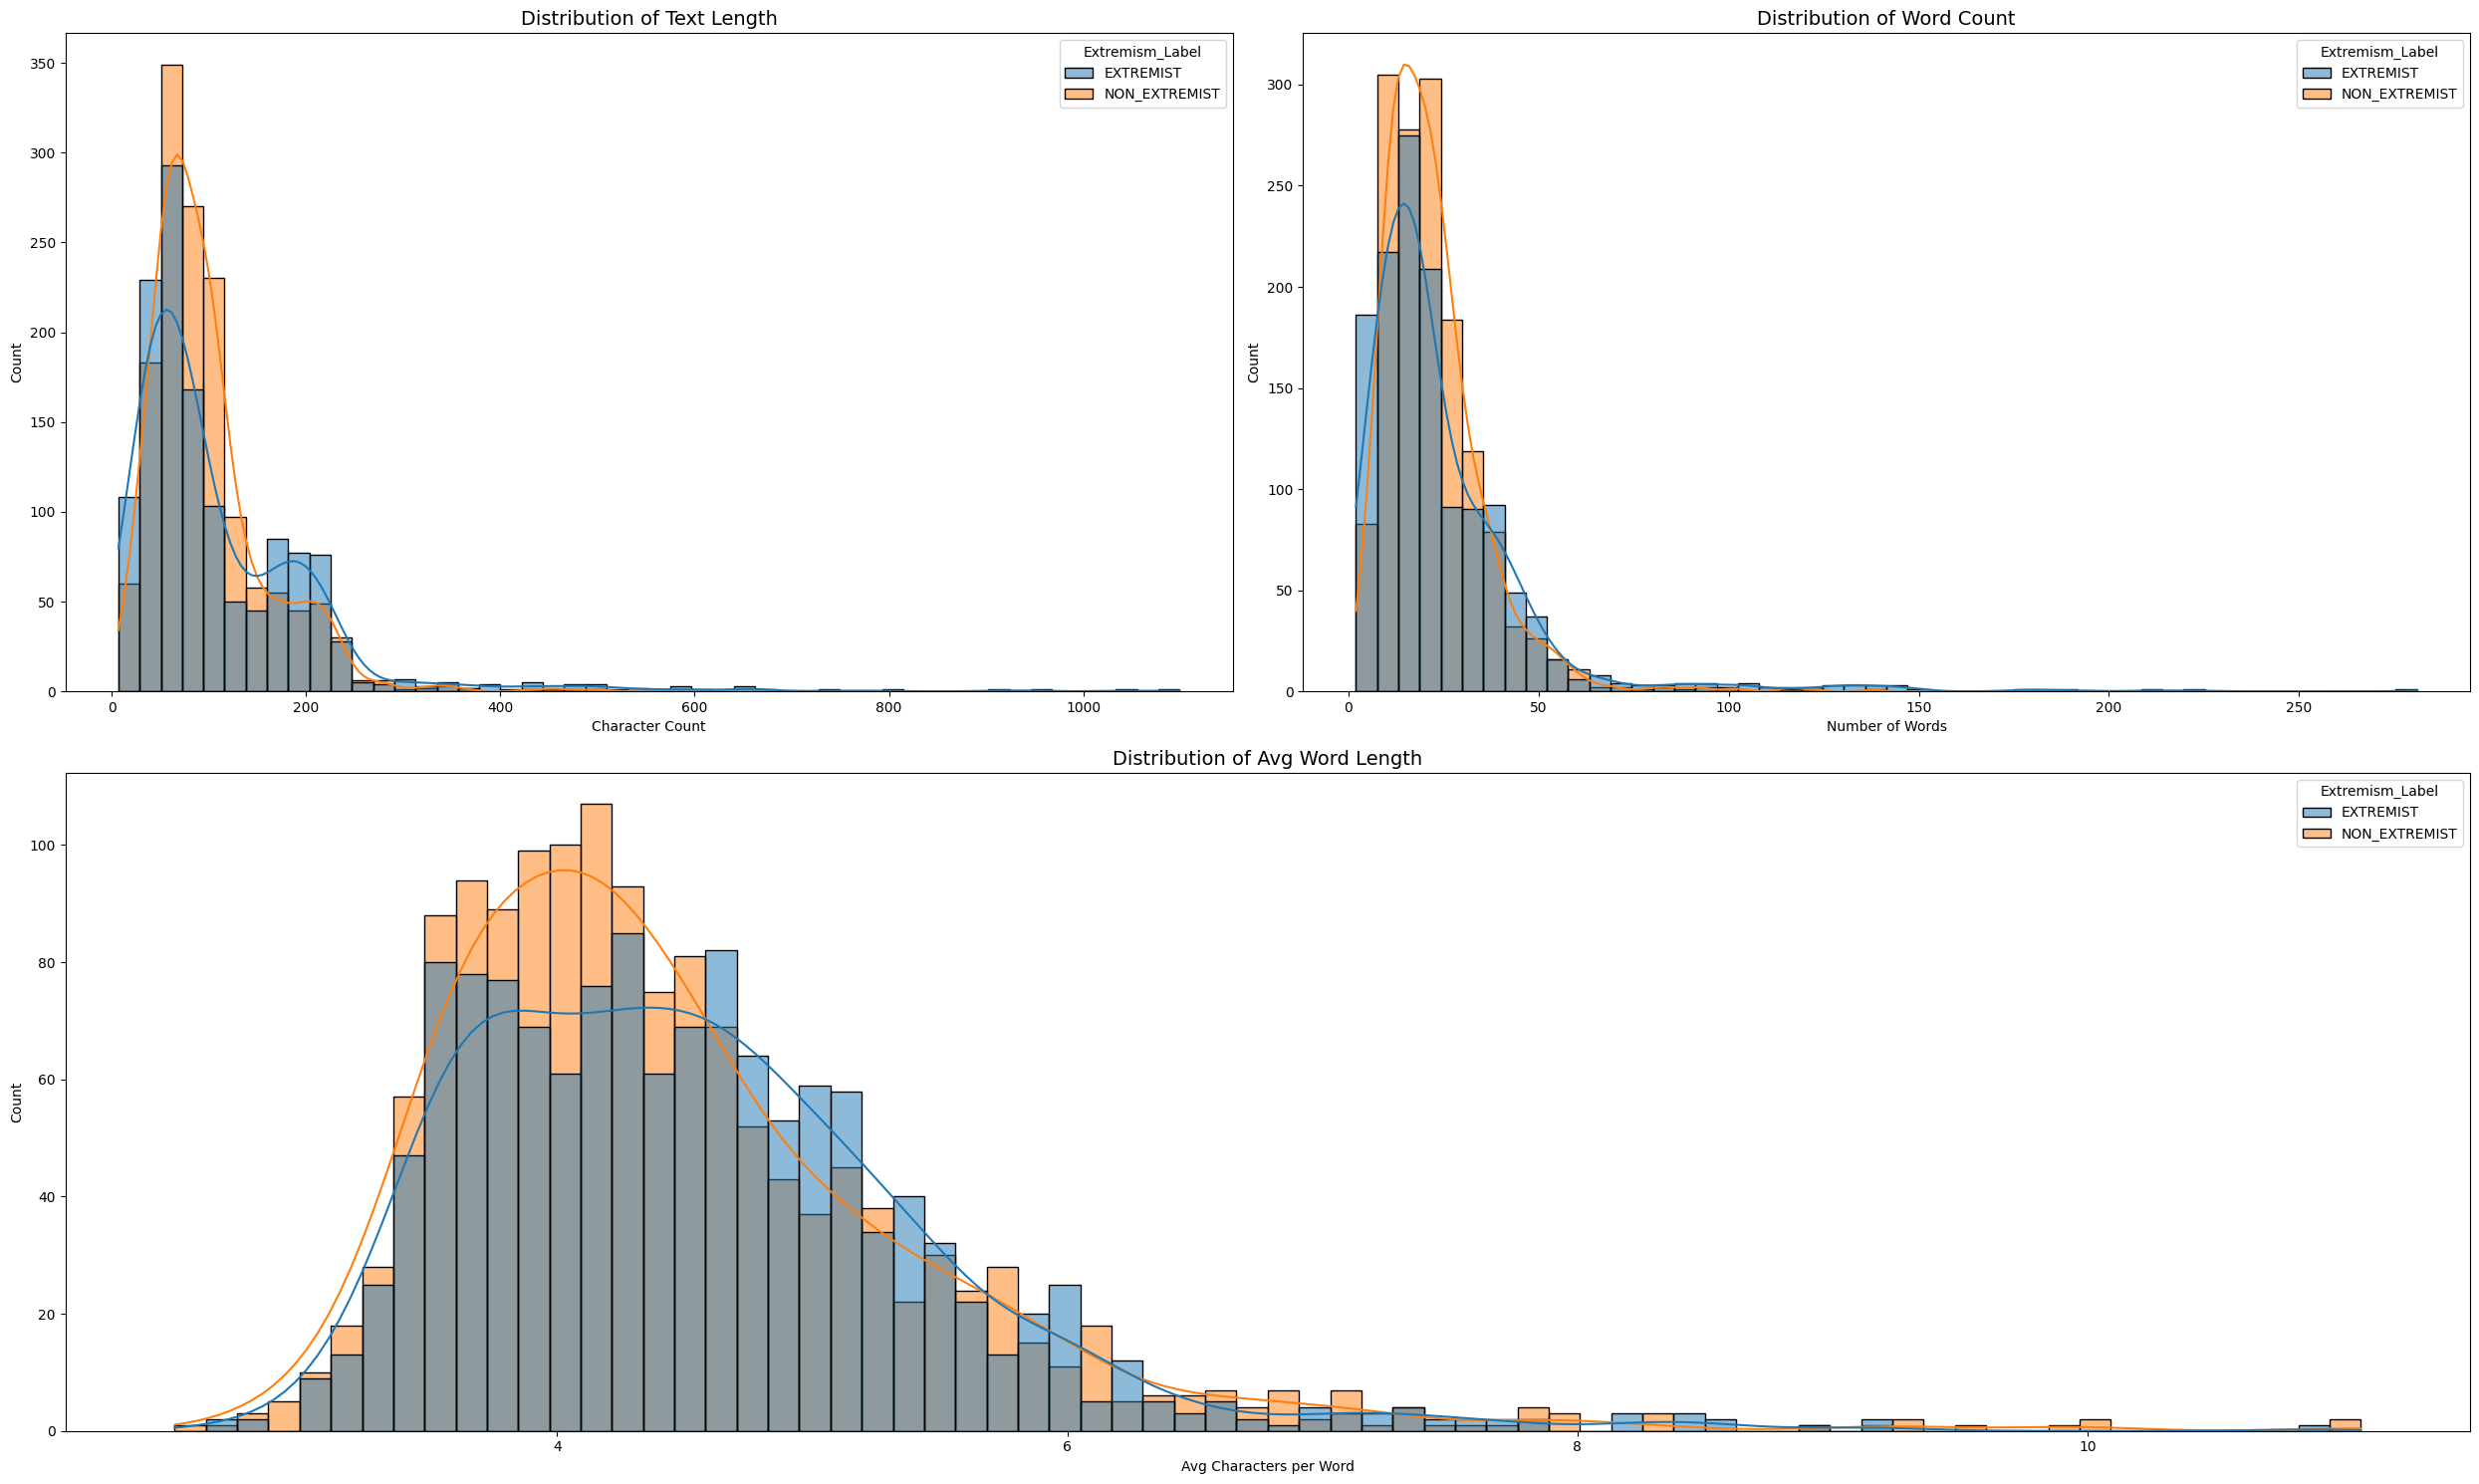

In [ ]:
# Visualization 2: Histogram
fig = plt.figure(figsize=(25, 15))
gs = gridspec.GridSpec(2, 2, figure=fig)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, :])

sns.histplot(data=df, x='text_lenght', hue='Extremism_Label', kde=True, bins=50, ax=ax1)
ax1.set_title('Distribution of Text Length', fontsize=14)
ax1.set_xlabel('Character Count')

sns.histplot(data=df, x='word_count', hue='Extremism_Label', kde=True, bins=50, ax=ax2)
ax2.set_title('Distribution of Word Count', fontsize=14)
ax2.set_xlabel('Number of Words')

sns.histplot(data=df, x='avg_word_length', hue='Extremism_Label', kde=True, bins=70, ax=ax3)
ax3.set_title('Distribution of Avg Word Length', fontsize=14)
ax3.set_xlabel('Avg Characters per Word')

plt.tight_layout()
plt.show()

* Linguistic Analysis
  * Top 20 most frequent words (overall)

In [ ]:
all_text = " ".join(df['Original_Message'].astype(str)).lower()
words = re.findall(r'\w+', all_text)
word_counts = Counter(words)
top_20 = word_counts.most_common(20)
top_20_list = []
for word, count in top_20:
  top_20_list.append(word)
print(f'Overall the top 20 most frequent words are: {top_20_list}')

Overall the top 20 most frequent words are: ['the', 'a', 'to', 'you', 'and', 'of', 'i', 'is', 'are', 'bitch', 'not', 'in', 'that', 'it', 'with', 'they', 'all', 'kill', 'for', 'do']


* Linguistic Analysis
  * Top 20 most frequent words per class

In [ ]:
all_extremist_text = " ".join(df.loc[df['Extremism_Label'] == 'EXTREMIST', 'Original_Message'].astype(str)).lower()
words_ext = re.findall(r'\w+', all_extremist_text)
ext_word_counts = Counter(words_ext)
ext_top_20 = ext_word_counts.most_common(20)
ext_top_20_list = []
for word, count in ext_top_20:
  ext_top_20_list.append(word)

all_non_extremist_text = " ".join(df.loc[df['Extremism_Label'] == 'NON_EXTREMIST', 'Original_Message'].astype(str)).lower()
words_non_ext = re.findall(r'\w+', all_non_extremist_text)
non_ext_word_counts = Counter(words_non_ext)
non_ext_top_20 = non_ext_word_counts.most_common(20)
non_ext_top_20_list = []
for word, count in non_ext_top_20:
  non_ext_top_20_list.append(word)

print(f'For EXTREMIST class, the top 20 most frequent words are: {ext_top_20_list}')
print(f'For NON_EXTREMIST class, the top 20 most frequent words are: {non_ext_top_20_list}')


For EXTREMIST class, the top 20 most frequent words are: ['the', 'to', 'and', 'of', 'you', 'a', 'are', 'i', 'is', 'kill', 'not', 'they', 'it', 'all', 'in', 'with', 'that', 'them', 'us', 'get']
For NON_EXTREMIST class, the top 20 most frequent words are: ['a', 'the', 'you', 'to', 'bitch', 'i', 'of', 'and', 'is', 'not', 'that', 'are', 'in', 'with', 'it', 'for', 'my', 'do', 'fucking', 'trump']


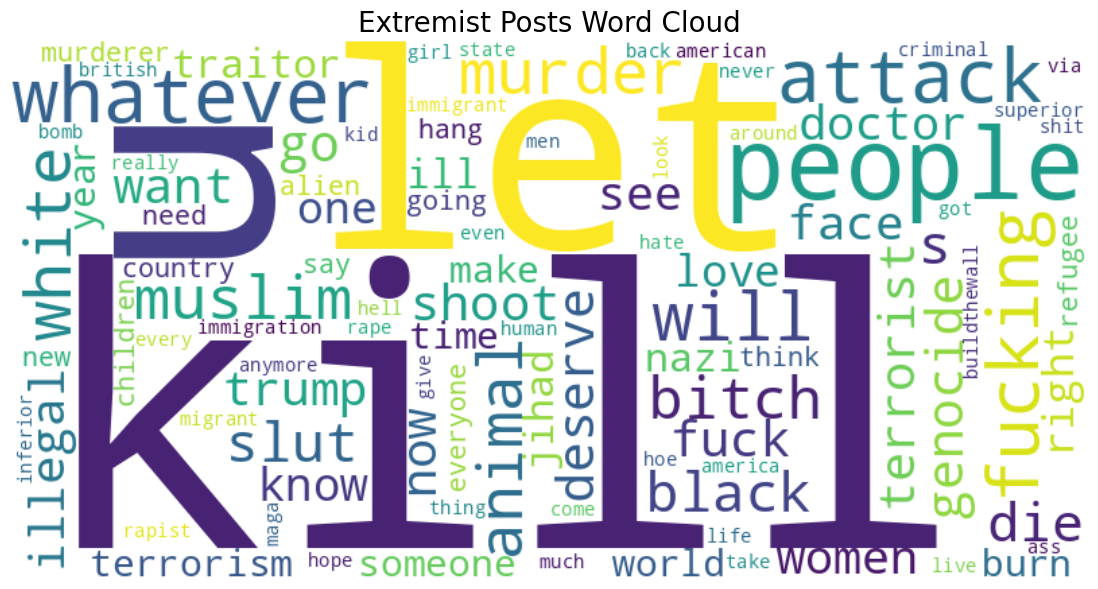

In [ ]:
# Wordcloud creation for both classes
wc = WordCloud(width=800, height=400, background_color='white', collocations=False, max_words=100)
plt.figure(figsize=(15, 7))

extremist_cloud = wc.generate(all_extremist_text)
plt.imshow(extremist_cloud, interpolation='bilinear')
plt.title('Extremist Posts Word Cloud', fontsize=20)
plt.axis('off')
plt.show()

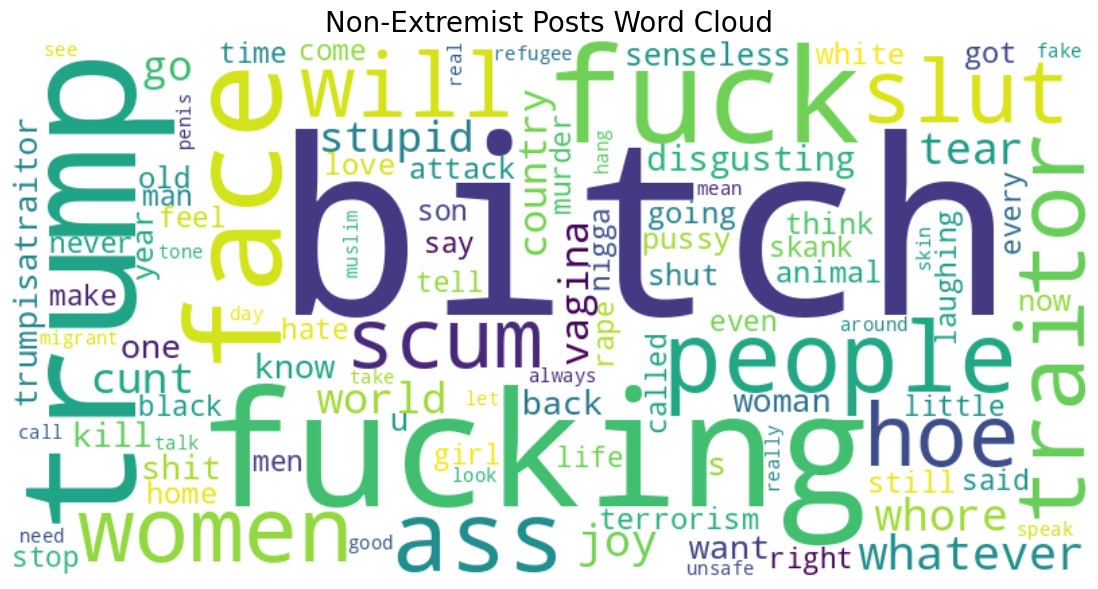

In [ ]:
plt.figure(figsize=(15, 7))

non_extremist_cloud = wc.generate(all_non_extremist_text)
plt.imshow(non_extremist_cloud, interpolation='bilinear')
plt.title('Non-Extremist Posts Word Cloud', fontsize=20)
plt.axis('off')

plt.show()

* Compare the most prominent words in each class

Visually, in each class the most prominent words are:
  * for Extremists posts: Let, Kill, U, people, attack
  * for Non-Extremists posts: bitch, fucking, fuck, trump, face

# B. Qualitative Analysis
* Dataset annotation and validation

In [ ]:
extremist_sample = df[df['Extremism_Label'] == 'EXTREMIST'].sample(n=15, random_state=42)
non_extremist_sample = df[df['Extremism_Label'] == 'NON_EXTREMIST'].sample(n=15, random_state=42)

all_sample = pd.concat([extremist_sample, non_extremist_sample]).sample(frac=1).reset_index(drop=True)

all_sample['id'] = range(1, len(all_sample) + 1)

annotation_df = pd.DataFrame({
    'id': all_sample['id'],
    'text': all_sample['Original_Message'],
    'annotator_1': "",
    'annotator_2': "",
    'annotator_3': "",
    'annotator_4': "",
    'annotator_5': "",
    'original_label': all_sample['Extremism_Label']
})

annotation_df.to_csv('mbd_annotation_sample_30.csv', index=False)

Krippendorff’s is a statistical measure of inter-rater reliability i.e., how much different rates when classifying data.
Helps answer are the raters agreeing more than would be expected by chance?
It works for different measurement levels i.e.,
- Nominal
- Ordinal
- Interval
- Ratio

It compares how much raters actually disagree vs how much disagreement would happen by chance.

In [ ]:
annotation_df=pd.read_csv('/content/mbd_annotation_sample_30.csv')

In [ ]:
import krippendorff

def pairwise_agreement(df, col1, col2):
  agreements = (df[col1] == df[col2]).sum()
  total = len(df)
  return agreements / total

def calculate_pairwise_disagreement(df, col1, col2):
  disagreements = (df[col1] != df[col2]).sum()
  total = len(df)
  disagreement_rate = disagreements / total

  disagreement_rows = df.loc[df[col1] != df[col2]]

  disagreement_data = {
      'pair_type': f"{col1} vs {col2}",
      'disagreement_count': disagreements,
      'total_examples': total,
      'disagreement_rate': round(disagreement_rate, 3),
      'disagreement_percentage': round(disagreement_rate * 100, 1),
      'text': disagreement_rows['text'].tolist() if 'text' in df.columns else [],
  }

  return disagreement_data

def compute_pairwise_alpha(df, columns, label):
    print(f"Pairwise Krippendorff’s alpha scores ({label}):\n")
    results = []
    for i in range(len(columns)):
        for j in range(i+1, len(columns)):
            print(f"Pair: {columns[i]} vs {columns[j]}")
            pair_data = [df[columns[i]].tolist(), df[columns[j]].tolist()] # gets annotations from each annotator and converts to list
            alpha = krippendorff.alpha(reliability_data=pair_data, level_of_measurement='nominal') # nominal-> assigns 0 if no disagreement else assigns 1. Result is no of disagreements /total comparisons
            results.append({'Rater_1': columns[i], 'Rater_2': columns[j], 'Krip_Alpha': round(alpha, 3)})
    return pd.DataFrame(results)

In [ ]:
annotator_columns = ['annotator_1', 'annotator_2', 'annotator_3', 'annotator_4','annotator_5']
agreement_res=[]
for i in range(len(annotator_columns)):
  for j in range(i+1, len(annotator_columns)):

    agreement_res.append(pairwise_agreement(annotation_df, annotator_columns[i], annotator_columns[j]))
    print(f"Pairwise Agreement between {annotator_columns[i]} and {annotator_columns[j]}:")
    print(pairwise_agreement(annotation_df, annotator_columns[i], annotator_columns[j]))

Pairwise Agreement between annotator_1 and annotator_2:
0.0
Pairwise Agreement between annotator_1 and annotator_3:
0.7
Pairwise Agreement between annotator_1 and annotator_4:
0.6
Pairwise Agreement between annotator_1 and annotator_5:
0.7333333333333333
Pairwise Agreement between annotator_2 and annotator_3:
0.0
Pairwise Agreement between annotator_2 and annotator_4:
0.0
Pairwise Agreement between annotator_2 and annotator_5:
0.0
Pairwise Agreement between annotator_3 and annotator_4:
0.7666666666666667
Pairwise Agreement between annotator_3 and annotator_5:
0.8333333333333334
Pairwise Agreement between annotator_4 and annotator_5:
0.6666666666666666


In [ ]:
print(compute_pairwise_alpha(annotation_df, annotator_columns, 'EXTREMIST'))
# print(compute_pairwise_alpha(annotation_df, annotator_columns, 'NON_EXTREMIST'))

Pairwise Krippendorff’s alpha scores (EXTREMIST):

Pair: annotator_1 vs annotator_2
Pair: annotator_1 vs annotator_3
Pair: annotator_1 vs annotator_4
Pair: annotator_1 vs annotator_5
Pair: annotator_2 vs annotator_3
Pair: annotator_2 vs annotator_4
Pair: annotator_2 vs annotator_5
Pair: annotator_3 vs annotator_4
Pair: annotator_3 vs annotator_5
Pair: annotator_4 vs annotator_5
       Rater_1      Rater_2  Krip_Alpha
0  annotator_1  annotator_2      -0.321
1  annotator_1  annotator_3       0.409
2  annotator_1  annotator_4       0.221
3  annotator_1  annotator_5       0.523
4  annotator_2  annotator_3      -0.320
5  annotator_2  annotator_4      -0.318
6  annotator_2  annotator_5      -0.317
7  annotator_3  annotator_4       0.550
8  annotator_3  annotator_5       0.729
9  annotator_4  annotator_5       0.396


In [ ]:

pairwise_disagreement_results = []
for i in range(len(annotator_columns)):
  for j in range(i+1, len(annotator_columns)):
    pairwise_disagreement_results.append(calculate_pairwise_disagreement(annotation_df, annotator_columns[i], annotator_columns[j]))

In [ ]:
pairwise_disagreement_results

[{'pair_type': 'annotator_1 vs annotator_2',
  'disagreement_count': np.int64(30),
  'total_examples': 30,
  'disagreement_rate': np.float64(1.0),
  'disagreement_percentage': np.float64(100.0),
  'text': ['jihadi john is a terrorist',
   'never a doubt that our founders saw the writing on the wall when they revolted against the british uk supports the muslim global caliphate christian refugees not welcome',
   'that one cock blocking ass bitch you can never get past',
   'whatever do not blow up our wives and children in the name an allah nor did whatever murder in darfur let us not compare apples and oranges',
   'i really sympathize for the kid at do not care office who answered my call i asked him how he feels about government approved murder and sexual trafficking of detained immigrant children he told me he feels awful but the congressman has no new comment',
   'a smuggler explains how he helped fighters along the jihad highway',
   'i would like to see every jewish ghetto burn 

Inter-Human Disagreement Rate

In [ ]:
annotator_cols = ['annotator_1', 'annotator_2',
                  'annotator_3', 'annotator_4',
                  'annotator_5']

# Count unique labels per row (ignoring original label)
annotation_df['unique_labels'] = annotation_df[annotator_cols].nunique(axis=1)

# Disagreement if more than 1 unique label
annotation_df['disagreement'] = annotation_df['unique_labels'] > 1

# All disagreement examples
disagreement_examples = annotation_df[annotation_df['disagreement'] == True]

print("Total examples with disagreement:", len(disagreement_examples))
disagreement_examples[['id', 'text', 'unique_labels']]

Total examples with disagreement: 30


,id,text,unique_labels
0,1,jihadi john is a terrorist,3
1,2,never a doubt that our founders saw the writin...,3
2,3,that one cock blocking ass bitch you can never...,2
3,4,whatever do not blow up our wives and children...,3
4,5,i really sympathize for the kid at do not care...,3
5,6,a smuggler explains how he helped fighters alo...,3
6,7,i would like to see every jewish ghetto burn t...,2
7,8,yet calling president trump and republicans na...,2
8,9,first of all ya penis is too mediocre to be ha...,2
9,10,my teacher is such a resentful son of a bitch ...,2


Inter-Human Disagreement Rate

In [ ]:
total_examples = len(annotation_df)
total_disagreements = annotation_df['disagreement'].sum()

disagreement_rate = total_disagreements / total_examples

print("Inter-human disagreement rate:", round(disagreement_rate, 3))

Inter-human disagreement rate: 1.0


Which Examples Had the Most Disagreement?

In [ ]:
# Sort by highest disagreement
most_disagreement = annotation_df.sort_values(by='unique_labels', ascending=False)

most_disagreement[['id', 'text', 'unique_labels']].head(5)

,id,text,unique_labels
0,1,jihadi john is a terrorist,3
1,2,never a doubt that our founders saw the writin...,3
3,4,whatever do not blow up our wives and children...,3
4,5,i really sympathize for the kid at do not care...,3
5,6,a smuggler explains how he helped fighters alo...,3


Majority Vote

In [ ]:
# Majority vote function
def majority_vote(row):
    return row[annotator_cols].mode()[0]

annotation_df['majority_label'] = annotation_df.apply(majority_vote, axis=1)

annotation_df[['id', 'majority_label', 'original_label']].head()

,id,majority_label,original_label
0,1,EXTREMIST,EXTREMIST
1,2,EXTREMIST,EXTREMIST
2,3,NON_EXTREMIST,NON_EXTREMIST
3,4,EXTREMIST,EXTREMIST
4,5,EXTREMIST,EXTREMIST


How Often Majority Agreed with Original Label

In [ ]:
annotation_df['majority_matches_original'] = (
    annotation_df['majority_label'] == annotation_df['original_label']
)

majority_agreement_rate = annotation_df['majority_matches_original'].mean()

print("Majority agreement with original label:",
      round(majority_agreement_rate, 3))

Majority agreement with original label: 0.933


Where Did Group Disagree with Original Labels?

In [ ]:
group_vs_original_disagreement = annotation_df[
    annotation_df['majority_matches_original'] == False
]

group_vs_original_disagreement[['id', 'text',
                                'majority_label',
                                'original_label']]

,id,text,majority_label,original_label
14,15,antifa is recruiting for a designated terroris...,EXTREMIST,NON_EXTREMIST
22,23,the fucking scum of the world trannies sensele...,EXTREMIST,NON_EXTREMIST


The results show a 100% inter-human disagreement rate, meaning that for every example at least one annotator disagreed with the others. This indicates that identifying extremist content in this dataset is highly subjective and often ambiguous. Several texts had three unique labels, suggesting strong differences in interpretation, especially in politically sensitive or indirectly harmful statements. Although disagreement was common, the majority vote still aligned with the original dataset labels in most cases, showing overall consistency with the dataset’s standards. However, in a few cases (IDs 15 and 23), the group labeled the content as EXTREMIST while the original label was NON_EXTREMIST, suggesting differences in how hate speech and extremism are defined. Overall, the findings highlight both the complexity of the task and the importance of clear annotation guidelines to improve labeling consistency.

###C. ML BASELINE MODEL[20]

In [ ]:
df.columns

Index(['Original_Message', 'Extremism_Label', 'text_lenght', 'word_count',
       'avg_word_length'],
      dtype='object')

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:

# Convert labels to numeric
df['Extremism_Label_numeric'] = df['Extremism_Label'].map({
    'NON_EXTREMIST': 0,
    'EXTREMIST': 1
})

# dataset spliting
X = df["Original_Message"]
y = df["Extremism_Label_numeric"]

# let create a part to hold our 30% names remain
# First split: Train (70%) and remain (30%)
X_train, X_remain, y_train, y_remain = train_test_split(
    X, y,
    test_size=0.30,
    stratify=y,
    random_state=42
)

# Second split: Validation (15%) and Test (15%)
X_val, X_test, y_val, y_test = train_test_split(
    X_remain, y_remain,
    test_size=0.50,
    stratify=y_remain,
    random_state=42
)



In [ ]:
# Print sizes
print("Train size:", round(len(X_train)/len(df),2)*100,"%")
print("Validation size:", round(len(X_val)/len(df),2)*100,"%")
print("Test size:", round(len(X_test)/len(df),2)*100,"%" )

Train size: 70.0 %
Validation size: 15.0 %
Test size: 15.0 %


In [ ]:
# Convert Text to TF-IDF Features
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer()

# Fit only on training data to avoid data leakage
X_train_tfidf = vectorizer.fit_transform(X_train)

# Transform validation and test (DO NOT fit again)
X_val_tfidf = vectorizer.transform(X_val)
X_test_tfidf = vectorizer.transform(X_test)


In [ ]:
# Train Logistic Regression (Default Parameters)
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

# Train only on training set
model.fit(X_train_tfidf, y_train)


LogisticRegression()

In [ ]:
# Evaluating on Validation Set (NOT Test!)
y_val_pred = model.predict(X_val_tfidf)


In [ ]:
from sklearn.metrics import classification_report

report = classification_report(
    y_val,
    y_val_pred,
    target_names=['NON_EXTREMIST', 'EXTREMIST']
)

print(report)



               precision    recall  f1-score   support

NON_EXTREMIST       0.81      0.84      0.83       218
    EXTREMIST       0.82      0.79      0.80       198

     accuracy                           0.82       416
    macro avg       0.82      0.82      0.82       416
 weighted avg       0.82      0.82      0.82       416



In [ ]:
report_df = pd.DataFrame(classification_report(y_val, y_val_pred, target_names=['NON_EXTREMIST', 'EXTREMIST'],output_dict=True)).transpose()

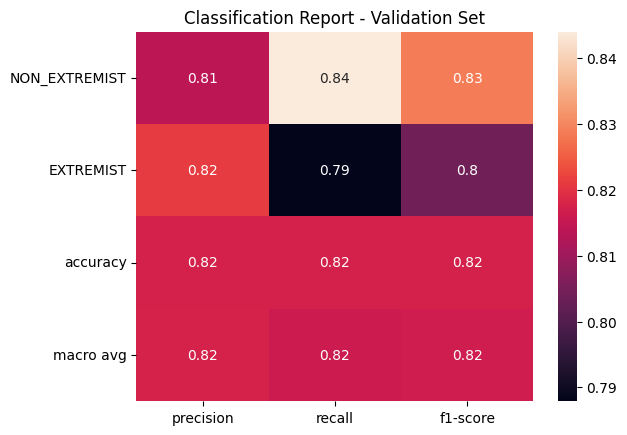

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure()
sns.heatmap(report_df.iloc[:-1, :-1], annot=True)
plt.title("Classification Report - Validation Set")
plt.show()


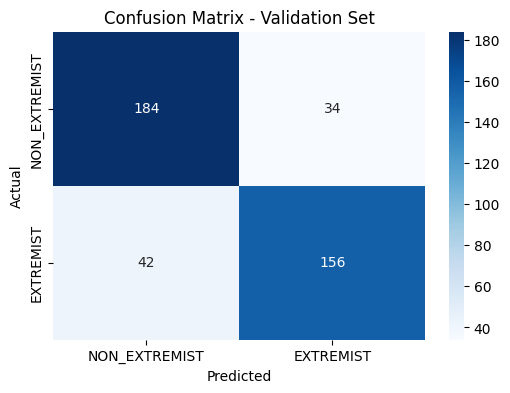

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_val, y_val_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['NON_EXTREMIST', 'EXTREMIST'],
            yticklabels=['NON_EXTREMIST', 'EXTREMIST'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Validation Set")
plt.show()


1.Systematic Error Review [10]

Identify ALL misclassifications (from the validation set) [5] <br>
Find ALL examples where model prediction != original label
Separate into False Positives and False Negatives [5]<br>
Save errors to CSV (as errors_validation_10.csv) for manual review

In [ ]:
label_map = {
    0: 'NON_EXTREMIST',
    1: 'EXTREMIST'
}



In [ ]:
errors = pd.DataFrame({
    'text': X_val.values,
    'true_label': y_val.map(label_map).values,
    'predicted_label': pd.Series(y_val_pred).map(label_map).values
})
errors = errors[errors['true_label'] != errors['predicted_label']]
errors

,text,true_label,predicted_label
1,some people are so messed up in the head that ...,NON_EXTREMIST,EXTREMIST
2,pass merit based immigration kill chain migrat...,NON_EXTREMIST,EXTREMIST
9,disarm them antifa please no one be stupid eno...,NON_EXTREMIST,EXTREMIST
22,leaving a pot on the stove can burn more than ...,NON_EXTREMIST,EXTREMIST
27,let this hoe touch this kid i swear to fucking...,EXTREMIST,NON_EXTREMIST
...,...,...,...
393,last after work i went to walmart while i what...,EXTREMIST,NON_EXTREMIST
402,my baby mama tripped and that bitch can shoot,NON_EXTREMIST,EXTREMIST
405,retweet the security rule applied to omar abdu...,NON_EXTREMIST,EXTREMIST
406,oh traitor put in prison for high crimes again...,EXTREMIST,NON_EXTREMIST


In [ ]:
# False Positive (FP) → predicted EXTREMIST but actually NON_EXTREMIST

false_positives = errors[
    (errors['true_label'] == 'NON_EXTREMIST') &
    (errors['predicted_label'] == 'EXTREMIST')
]

false_positives


,text,true_label,predicted_label
1,some people are so messed up in the head that ...,NON_EXTREMIST,EXTREMIST
2,pass merit based immigration kill chain migrat...,NON_EXTREMIST,EXTREMIST
9,disarm them antifa please no one be stupid eno...,NON_EXTREMIST,EXTREMIST
22,leaving a pot on the stove can burn more than ...,NON_EXTREMIST,EXTREMIST
111,hey these hashtags came up under your name for...,NON_EXTREMIST,EXTREMIST
112,game of fall fitting to kill some hoes,NON_EXTREMIST,EXTREMIST
116,watch austria threatens to deploy the army and...,NON_EXTREMIST,EXTREMIST
118,got to love an eon a morning panic attack ches...,NON_EXTREMIST,EXTREMIST
119,if i ever saw kendall jones in person i d kill...,NON_EXTREMIST,EXTREMIST
120,imagine your dying with cancer or with a fatal...,NON_EXTREMIST,EXTREMIST


In [ ]:

# False Negative (FN) → predicted NON_EXTREMIST but actually EXTREMIST
false_negatives = errors[
    (errors['true_label'] == 'EXTREMIST') &
    (errors['predicted_label'] == 'NON_EXTREMIST')
]
false_negatives

,text,true_label,predicted_label
27,let this hoe touch this kid i swear to fucking...,EXTREMIST,NON_EXTREMIST
49,this is all a lie folks thats why kushner what...,EXTREMIST,NON_EXTREMIST
82,on me i am about to have this bitch blasted i ...,EXTREMIST,NON_EXTREMIST
97,i am really wondering when fakedonaldtrump wil...,EXTREMIST,NON_EXTREMIST
125,ayo i just had a mini heart attack behind the ...,EXTREMIST,NON_EXTREMIST
132,i say hang is ass in the center of the town to...,EXTREMIST,NON_EXTREMIST
135,every supporter of the current white house occ...,EXTREMIST,NON_EXTREMIST
136,retweet if you verbally abuse a fuck boy is it...,EXTREMIST,NON_EXTREMIST
142,wakeupamerica do not think for a second anyone...,EXTREMIST,NON_EXTREMIST
146,pigs are disgusting animals only good for saus...,EXTREMIST,NON_EXTREMIST


In [ ]:
# saving the error
errors.to_csv("errors_validation_10.csv", index=False)


## Miss classified lables
1. leaving a pot on the stove can burn more than just your dinner always stay in the kitchen while cooking more tips here (NON-EXTREMIST  classified as EXTREMIST) -> I think it is due to the context i.e., always stay in the kitchen while cooking and they have mentioned leaving pot on stove can burn more than dinner i.e., can it burn you if you stay in the kitchen? since it is inducing harm i think that is why it was missclassified.
2. hey these hashtags came up under your name for some reason murderer killer guilty guilty double murder brentwood naked gun -> Non extremist classified as extremist, this can be due to trigger words and extremism content although it is a text that is more of infoming as opposed to inducing harm.
3. if i ever saw kendall jones in person i d kill her on sight i hate that bitch more than anything in life -> Labled as Non extremist but model predicted extremist. I think it is due to the strong violent language i.e., kill her on site which is more personal and not targeting a group thus not fitting to extremist but the model might have prioritized the violent words in clasifying.
4. someone on facebook made a status defending him so i dropped a bomb full of knowledge on that bitch and unfriended -> Predicted as extremist, i think its due to the use of drop a bomb which the model might think as being targeted attack/violence.
5. got to love an eon a morning panic attack chest pains anxiety dickhead bpd. -> model might be sensitive to threat indicators i.e., panic attack is taken as harm thus the flagging.
6. ack of ethic... bringbackhangingfortreason trumpisatraitor.-> Predicted as Non extremist, this is a political target.
7. every supporter of the current white house occupant who continues to support him after his latest treasonous comments can all fuck right the fuck off... trumpisatraitor. -> Targeting and triggering a group of supproters and suggesting for their exlusion. predicted as Non Extremist as it does not contain the heavy extrimism words.
8. retweet if you verbally abuse a fuck boy is it considered animal cruelty asking for a friend. Labeled as Non extremism, this can be due to the last part, asking for a friend although the statement is dehumanizing it can slip as a form of sarcasm.
9. my baby mama tripped and that bitch can shoot -> Predicted as Extremist, this is likely due to "can shoot" as it can be a slang word tied to skill but the model sees this as a violent action.
10. let this hoe touch this kid i swear to fucking god i will murder you bitch facts-> Model predicts as Non Extremist despite being a murder threat and it is a direct threat compared to the kendal one where its more of like a fame based hate without clear plan as opposed to this one where it is "i will murder you".

## Pattern
- Extremist is mostly due to overtriggered words, mixup e.g., the cooking example and the one for murder hashtags which is informative but since it contains heavy extremist words it gets wrongly classified.
- Non Extremist: Individual threats not considered as extremist and only looking at mostly the group tied extremism. E.g., let this hoe touch this kid i swear I will fucking kill you. Also when the content sarcarsm or jokes it might be wrongly classifed as Non Extremis.

In [ ]:
# Miss classified labels

## D. 2) Specific Improvements

Baseline Performance

In [ ]:
# Baseline Model vectorized with simple TF-IDF

baseline_model = LogisticRegression(max_iter=1000)
baseline_model.fit(X_train_tfidf, y_train)

baseline_pred = baseline_model.predict(X_test_tfidf)

baseline_accuracy = accuracy_score(y_test, baseline_pred)

print("Baseline Accuracy:", baseline_accuracy)
print(classification_report(y_test, baseline_pred))

Baseline Accuracy: 0.8177458033573142
              precision    recall  f1-score   support

           0       0.83      0.83      0.83       218
           1       0.81      0.81      0.81       199

    accuracy                           0.82       417
   macro avg       0.82      0.82      0.82       417
weighted avg       0.82      0.82      0.82       417



### Improvement 1:
Using TF-IDF with bigrams (1–2 grams)
Add class balancing

Implementation of the Improved Model

In [ ]:
# Improved TF-IDF
vectorizer_improved = TfidfVectorizer(
    ngram_range=(1,2),
    max_features=5000,
    stop_words='english'
)

X_improved = vectorizer_improved.fit_transform(df['Original_Message'])

y = df['Extremism_Label_numeric']

# Train-test split
X_train_imp, X_test_imp, y_train_imp, y_test_imp = train_test_split(
    X_improved, y, test_size=0.2, random_state=42
)

Training The Improved Model

In [ ]:
improved_model = LogisticRegression(
    class_weight='balanced',
    max_iter=1000
)

improved_model.fit(X_train_imp, y_train_imp)

improved_pred = improved_model.predict(X_test_imp)

improved_accuracy = accuracy_score(y_test_imp, improved_pred)

print("Improved Accuracy:", improved_accuracy)
print(classification_report(y_test_imp, improved_pred))


Improved Accuracy: 0.8345323741007195
              precision    recall  f1-score   support

           0       0.87      0.80      0.83       289
           1       0.80      0.87      0.83       267

    accuracy                           0.83       556
   macro avg       0.84      0.84      0.83       556
weighted avg       0.84      0.83      0.83       556



In [ ]:
# Compare Results
print("Baseline Accuracy:", baseline_accuracy)
print("Improved Accuracy:", improved_accuracy)


Baseline Accuracy: 0.8177458033573142
Improved Accuracy: 0.8345323741007195


Confusion Matrix

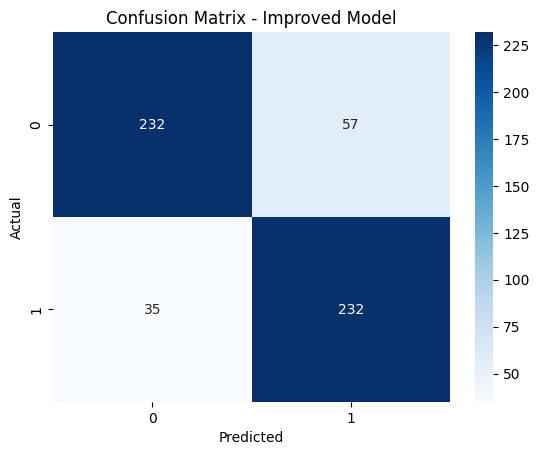

In [ ]:
cm = confusion_matrix(y_test_imp, improved_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Improved Model")
plt.show()


## Improvement 2:
Using Hyperparameter Tuning (C parameter for LR regularization)

In [ ]:
from sklearn.model_selection import GridSearchCV

parameter_grid = {'C': [0.01, 0.1, 1, 10, 100]}

hyperparam_tuned_model = GridSearchCV(
    LogisticRegression(class_weight='balanced', max_iter=1000),
    parameter_grid,
    cv=5,
    scoring='f1_macro'
)

hyperparam_tuned_model.fit(X_train_tfidf, y_train)

hyperparam_tuned_model_pred = hyperparam_tuned_model.predict(X_val_tfidf)

hyperparam_tuned_model_acc = accuracy_score(y_test_imp, improved_pred)

print("Improved Accuracy:", hyperparam_tuned_model_acc)
print(classification_report(
    y_val,
    hyperparam_tuned_model_pred,
    target_names=['NON_EXTREMIST', 'EXTREMIST']
))

Improved Accuracy: 0.8345323741007195
               precision    recall  f1-score   support

NON_EXTREMIST       0.83      0.82      0.82       218
    EXTREMIST       0.80      0.81      0.81       198

     accuracy                           0.81       416
    macro avg       0.81      0.81      0.81       416
 weighted avg       0.82      0.81      0.81       416



In [ ]:
print("Baseline Accuracy:", baseline_accuracy)
print("Improved Accuracy:", improved_accuracy)

Baseline Accuracy: 0.8177458033573142
Improved Accuracy: 0.8345323741007195


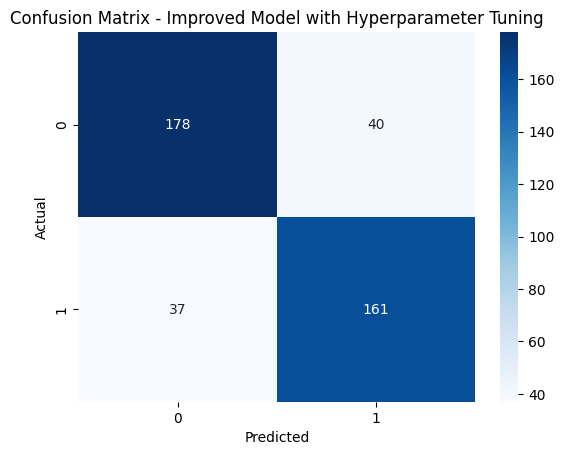

In [ ]:
cm = confusion_matrix(y_val, hyperparam_tuned_model_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Improved Model with Hyperparameter Tuning")
plt.show()


## Improvement 3:

Balanced Model on Validation Set

In [ ]:
model_balanced = LogisticRegression(class_weight='balanced', random_state=42)

model_balanced.fit(X_train_tfidf, y_train)


LogisticRegression(class_weight='balanced', random_state=42)

Classification Report (Balanced Model)
              precision    recall  f1-score   support

           0       0.83      0.82      0.82       218
           1       0.81      0.81      0.81       198

    accuracy                           0.82       416
   macro avg       0.82      0.82      0.82       416
weighted avg       0.82      0.82      0.82       416



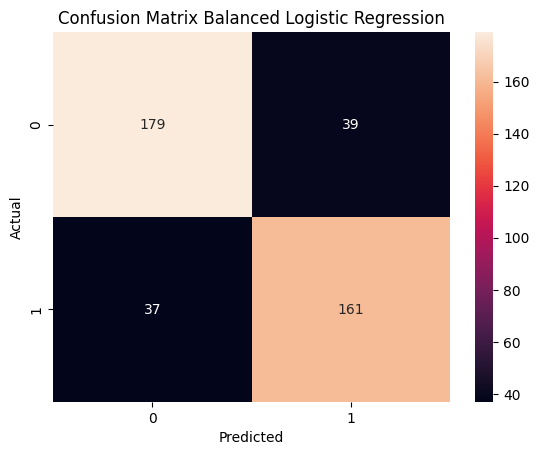

In [ ]:

# Validation predictions
y_val_pred_balanced = model_balanced.predict(X_val_tfidf)

# Classification Report
print("Classification Report (Balanced Model)")
print(classification_report(y_val, y_val_pred_balanced))

# Confusion Matrix
cm_balanced = confusion_matrix(y_val, y_val_pred_balanced)

plt.figure()
sns.heatmap(cm_balanced, annot=True, fmt='d')
plt.title("Confusion Matrix Balanced Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()
